# Mock Obstacles Tutorial for Perception Team

This notebook demonstrates how to use the `mock_obstacles` module for developing and testing the perception system.

## Overview

The mock obstacles module provides three types of geometric primitives that implement the `ray_intersect()` interface:

1. **MockSphere** - Spherical obstacles (useful for simple collision testing)
2. **MockPlane** - Infinite plane obstacles (walls, floors, boundaries)
3. **MockBox** - Axis-aligned bounding boxes (rectangular obstacles)

## Interface Contract

All mock obstacles implement the same interface:

```python
def ray_intersect(
    self, 
    origin: np.ndarray,      # shape=(3,) - starting point of ray
    direction: np.ndarray,   # shape=(3,) - normalized direction vector
    max_distance: float      # maximum distance to check
) -> Optional[Tuple[float, np.ndarray, np.ndarray]]:
    """
    Returns: (distance, hit_point, normal) or None if no hit
    - distance: float - distance from origin to hit point
    - hit_point: np.ndarray shape=(3,) - 3D coordinates of intersection
    - normal: np.ndarray shape=(3,) - surface normal at hit point
    """
```

This interface allows the perception team to develop ray casting independently of the obstacles team's implementation.


## Setup and Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from flockrl_sim.perception.mock_obstacles import MockSphere, MockPlane, MockBox

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

def normalize_rays(test_rays):
    """Normalize ray directions."""
    return [(origin, direction / np.linalg.norm(direction)) for origin, direction in test_rays]

def visualize_rays(ax, test_rays, results, colors=['red', 'blue']):
    """Visualize ray origins, rays, and hit points."""
    for i, ((origin, direction), result) in enumerate(zip(test_rays, results)):
        ax.scatter(*origin, color=colors[i], s=200, marker='s', 
                  edgecolors='black', linewidth=2, zorder=10)
        
        if result:
            distance, hit_point, normal = result
            ax.plot([origin[0], hit_point[0]], [origin[1], hit_point[1]], [origin[2], hit_point[2]], 
                    color=colors[i], linewidth=3, alpha=0.8)
            ax.scatter(*hit_point, color='yellow', s=150, marker='*', 
                      edgecolors=colors[i], linewidth=3, zorder=10)
        else:
            end = origin + direction * 2.0
            ax.plot([origin[0], end[0]], [origin[1], end[1]], [origin[2], end[2]], 
                    color=colors[i], linewidth=2, linestyle='--', alpha=0.5)

def setup_axes(ax, xlim=None, ylim=None, zlim=None):
    """Set up common axis properties."""
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)
    if zlim: ax.set_zlim(zlim)
    ax.set_box_aspect([1, 1, 1])


## 1. MockSphere - Spherical Obstacles

Spheres are the simplest obstacle type and are perfect for testing basic ray intersection logic.

Let's create a sphere and **cast rays FROM positions outside the sphere TOWARD it** to see where they hit the surface.


In [2]:
sphere = MockSphere(center=[1.0, 1.0, 1.0], radius=0.8)

test_rays = [
    (np.array([-1.0, 1.0, 1.0]), np.array([1.0, 0.0, 0.0])),
    (np.array([1.0, 1.0, 3.0]), np.array([0.0, 0.0, -1.0])),
]

test_rays = normalize_rays(test_rays)
results = [sphere.ray_intersect(origin, direction, 10.0) for origin, direction in test_rays]


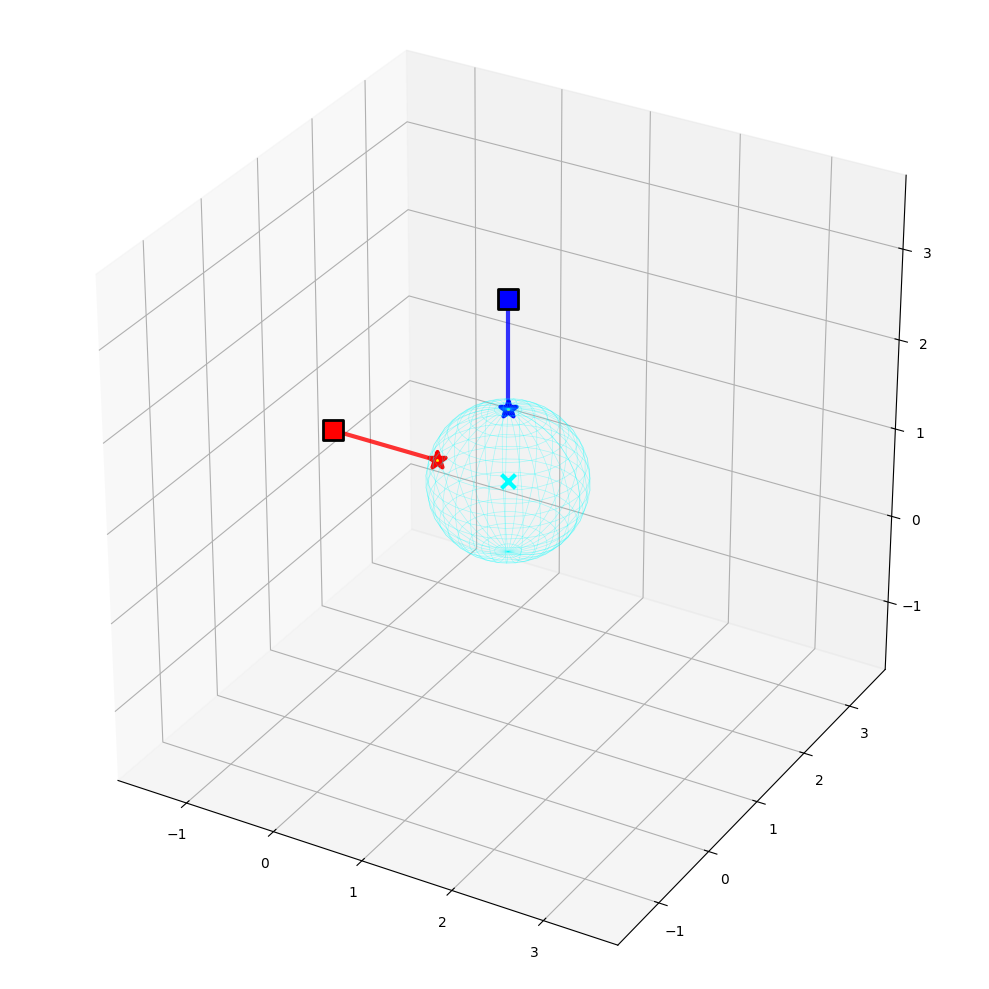

In [3]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Draw sphere wireframe
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 20)
x_sphere = sphere.center[0] + sphere.radius * np.outer(np.cos(u), np.sin(v))
y_sphere = sphere.center[1] + sphere.radius * np.outer(np.sin(u), np.sin(v))
z_sphere = sphere.center[2] + sphere.radius * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='cyan', alpha=0.3, linewidth=0.5)

ax.scatter(*sphere.center, color='cyan', s=100, marker='x', linewidths=3)
visualize_rays(ax, test_rays, results)
setup_axes(ax,
          xlim=[sphere.center[0] - sphere.radius - 2, sphere.center[0] + sphere.radius + 2],
          ylim=[sphere.center[1] - sphere.radius - 2, sphere.center[1] + sphere.radius + 2],
          zlim=[sphere.center[2] - sphere.radius - 2, sphere.center[2] + sphere.radius + 2])
plt.tight_layout()
plt.show()


## 2. MockPlane - Infinite Planes

Planes are useful for representing walls, floors, and boundaries. A plane is defined by a point on the plane and a normal vector.

Let's create a ground plane and a wall plane.


In [4]:
ground = MockPlane(point=[0.0, 0.0, 0.0], normal=[0.0, 0.0, 1.0])
wall = MockPlane(point=[0.0, 3.0, 0.0], normal=[0.0, -1.0, 0.0])

test_rays = [
    (np.array([1.0, 1.0, 2.0]), np.array([0.0, 0.0, -1.0])),
    (np.array([0.0, 0.0, 1.0]), np.array([0.0, 1.0, 0.0])),
]

test_rays = normalize_rays(test_rays)


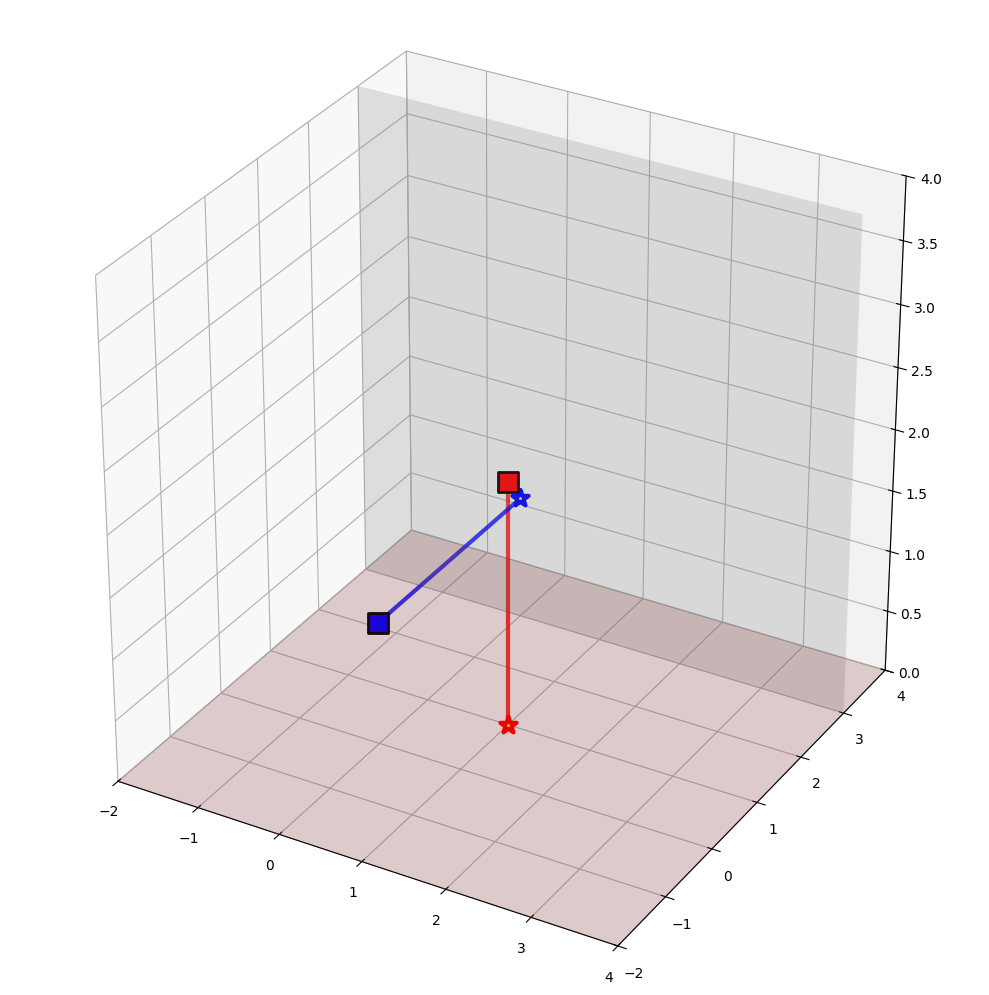

In [5]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Draw planes
xx, yy = np.meshgrid(np.linspace(-2, 4, 10), np.linspace(-2, 4, 10))
ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.2, color='brown')

xx_wall, zz_wall = np.meshgrid(np.linspace(-2, 4, 10), np.linspace(0, 4, 10))
ax.plot_surface(xx_wall, np.ones_like(xx_wall) * 3.0, zz_wall, alpha=0.2, color='gray')

results = [ground.ray_intersect(origin, direction, 10.0) or wall.ray_intersect(origin, direction, 10.0) 
           for origin, direction in test_rays]
visualize_rays(ax, test_rays, results)
setup_axes(ax, xlim=[-2, 4], ylim=[-2, 4], zlim=[0, 4])
plt.tight_layout()
plt.show()


## 3. MockBox - Axis-Aligned Bounding Boxes

Boxes are useful for representing rectangular obstacles like buildings, containers, or barriers. They're defined by minimum and maximum corner points.

Let's create a box and test ray intersections from different angles.


In [6]:
box = MockBox(min_corner=[0.0, 0.0, 0.0], max_corner=[2.0, 2.0, 2.0])

test_rays = [
    (np.array([-1.0, 1.0, 1.0]), np.array([1.0, 0.0, 0.0])),
    (np.array([3.0, 3.0, 1.0]), np.array([-1.0, -1.0, 0.0])),
]

test_rays = normalize_rays(test_rays)
results = [box.ray_intersect(origin, direction, 10.0) for origin, direction in test_rays]


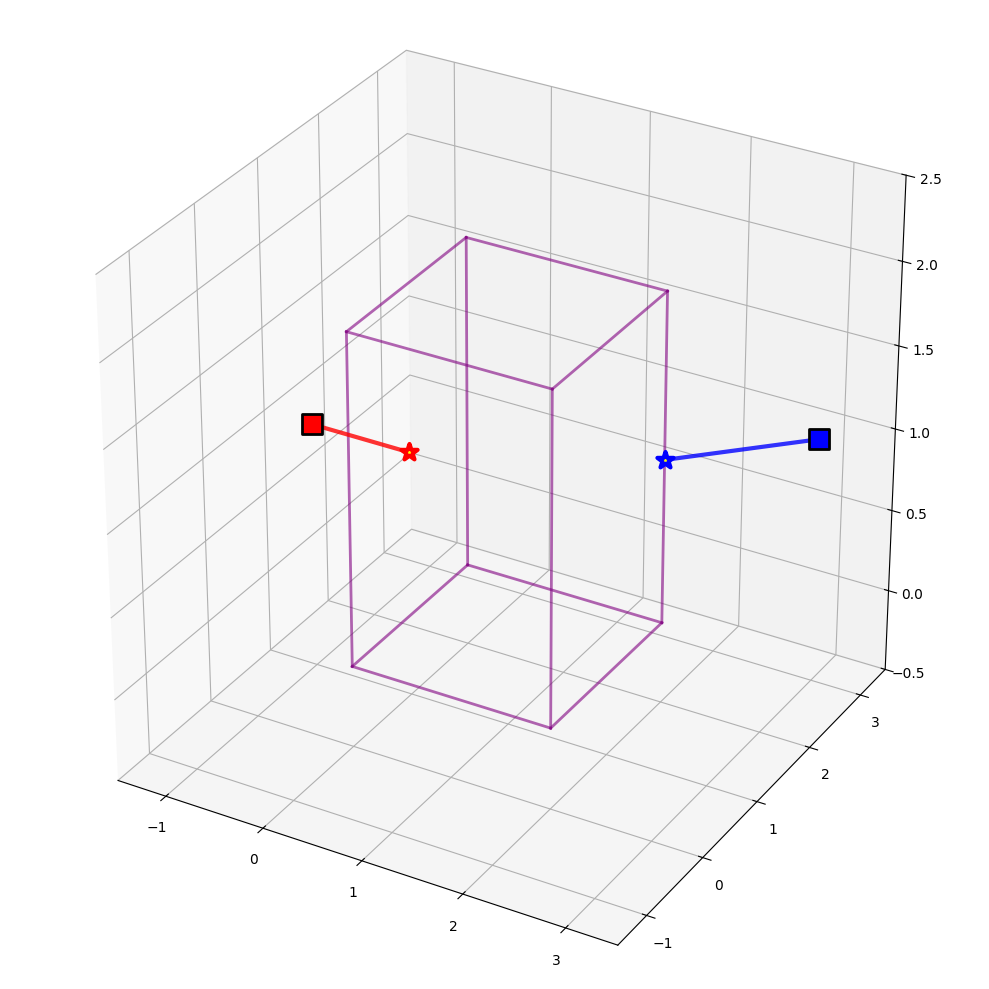

In [7]:
def draw_box_wireframe(ax, min_corner, max_corner, color='black', alpha=0.3):
    vertices = np.array([
        [min_corner[0], min_corner[1], min_corner[2]],
        [max_corner[0], min_corner[1], min_corner[2]],
        [max_corner[0], max_corner[1], min_corner[2]],
        [min_corner[0], max_corner[1], min_corner[2]],
        [min_corner[0], min_corner[1], max_corner[2]],
        [max_corner[0], min_corner[1], max_corner[2]],
        [max_corner[0], max_corner[1], max_corner[2]],
        [min_corner[0], max_corner[1], max_corner[2]],
    ])
    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7],
    ]
    for edge in edges:
        ax.plot3D(*vertices[edge].T, color=color, alpha=alpha, linewidth=2)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

draw_box_wireframe(ax, box.min_corner, box.max_corner, color='purple', alpha=0.6)
visualize_rays(ax, test_rays, results)
setup_axes(ax, xlim=[-1.5, 3.5], ylim=[-1.5, 3.5], zlim=[-0.5, 2.5])
plt.tight_layout()
plt.show()
